In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits

# import utils.map_processing

# from utils.map_processing import get_cleaned_temperature_field

# HEALPix map resolution
# nside = 2048

In [2]:
### 143 and 217 GHz point source masks ???
### fsky_planck_only = 0.67063
### fsky_final = 0.586

mask = nmt.mask_apodization(hp.read_map("/home/gscianna/codes/CMBxunWISE/masks/mask.fits"), 1., apotype="Smooth")
fsky = np.mean(mask)
print(fsky)

0.05934359960897053


In [3]:
def get_cleaned_temperature_field():
    
    hdul = fits.open("/home/gscianna/codes/CMBxunWISE/maps/SMICA-noSZ.fits")

    T_nested = hdul[1].data["I_STOKES"].reshape(-1)     # or: .flatten() to reshape the data to a 1D array
    T_ring = hp.reorder(T_nested, n2r=True)     # convert from NESTED to RING ordering

    cmb_data = np.array(T_ring, dtype=np.float64)

    # remove monopole/dipole
    cmb_clean, monopole, dipole = hp.remove_dipole(cmb_data, fitval=True)
    cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)

    return cmb_clean

In [4]:
cmb_map = get_cleaned_temperature_field()
nside = hp.get_nside(cmb_map)

In [5]:
l_min = 300
l_max = 2900
delta_l = 200

In [6]:
def get_filtered_angular_power_spectrum(cmb_map, l_max):

    ell = np.arange(l_max + 1) # multipole moments from 0 to l_max

    filter = np.loadtxt("/home/gscianna/codes/CMBxunWISE/maps/filter.txt") #2D array that contains ell in first column
                                              #and mask values in second column
    print(filter.shape)
    filter = filter[:l_max + 1, :]

    FWMN = 5.0  # full width at half maximum of the beam in arcminutes
    FWHM = FWMN * np.pi / (180 * 60)  # convert FWHM from arcminutes to radians
    beam = np.exp(-0.5 * ell * (ell + 1) * (FWHM / np.sqrt((8 * np.log(2))))**2)
    filter_tot = filter[:, 1] * beam

    alm = hp.map2alm(cmb_map, lmax=l_max, pol=False)

    alm_filtered = hp.almxfl(alm, filter_tot)
    cl_filtered = hp.alm2cl(alm_filtered)    # angular power spectrum C_l of the filtered alm coefficients
    ell = np.arange(len(cl_filtered))

    # plt.figure(figsize=(8,5))
    # plt.plot(ell, filter_tot, label="filter_tot")
    # plt.plot(ell, filter[:, 1], label="filter")
    # plt.plot(ell, beam, label="beam")
    # plt.xlabel(r"$\ell$")
    # plt.ylabel("filter")
    # plt.legend()
    # plt.grid(alpha=0.3)
    # plt.show()

    # plt.figure(figsize=(8,5))
    # plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl_filtered[2:] / (2*np.pi), label='Filtered')
    # plt.xlabel(r"$\ell$")
    # plt.ylabel(r"$D_\ell$")
    # plt.title("Temperature power spectrum")
    # plt.grid(alpha=0.3)
    # plt.show()

    # print(alm_filtered.shape)
    # print(cl_filtered.shape)
    # print(ell.shape)
    # print(hp.Alm.getsize(l_max))

    return alm_filtered, cl_filtered, ell

##### do the filtering in harmonic space; through hp.alm2map generate the filtered CMB temperature map; square it in pixel space; through hp.map2alm get the alms of the new map and compute cls

In [7]:
def get_tsquared_angular_power_spectrum(alm_filtered, nside, l_max):
    
    nside = hp.get_nside(cmb_map)
    temp_filtered = hp.alm2map(alm_filtered, nside=nside, lmax=l_max)
    temp_filtered_squared = temp_filtered**2

    # hp.mollview(temp_filtered_squared, title="Filtered temperature squared map", unit=r"$\mu K^2$", norm="hist")
        
    alm_squared = hp.map2alm(temp_filtered_squared, lmax=l_max, pol=False)
    cl_squared = hp.alm2cl(alm_squared, lmax=l_max)
    ell = np.arange(len(cl_squared))

    # plt.figure(figsize=(8, 5))
    # plt.plot(ell[2:], cl_squared[2:], label="Filtered T²")
    # plt.xlabel(r"$\ell$")
    # plt.ylabel(r"$C_\ell$")
    # plt.xlim(2, l_max)
    # plt.yscale("log")
    # plt.title("Power spectrum of filtered temperature squared map")
    # plt.grid(alpha=0.3)
    # plt.legend()
    # plt.show()

    return ell, cl_squared, temp_filtered_squared

In [8]:
# generate a Gaussian random field based on the temperature power spectrum

# def get_sample_temperature_field():
#     mp_t = hp.synfast(cl_tt, nside, pol=False)
#     return nmt.NmtField(mask, [mp_t])

# We also copy this function from sample_workspaces.py. It computes
# power spectra given a pair of fields and a workspace.

def compute_master(f_a, f_b, wsp):
    cl_coupled = nmt.compute_coupled_cell(f_a, f_b)
    cl_decoupled = wsp.decouple_cell(cl_coupled)

    return cl_decoupled

# cl_bias = nmt.deprojection_bias(f_a, f_b, cl_guess)

In [9]:
alm_filtered, cl_filtered, ell = get_filtered_angular_power_spectrum(cmb_map, l_max)
ell, cl_squared, temp_filtered_squared = get_tsquared_angular_power_spectrum(alm_filtered, nside, l_max)

(3001, 2)


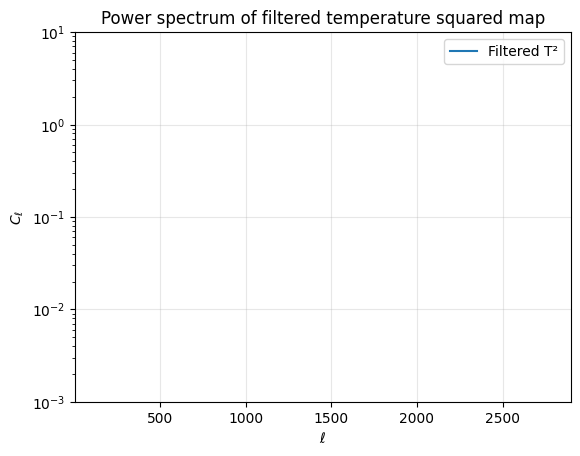

In [ ]:
cl_squared

plt.plot(np.arange(len(cl_squared)), cl_squared, label="Filtered T²")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.xlim(2, l_max)
plt.yscale("log")
plt.title("Power spectrum of filtered temperature squared map")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### binning scheme

In [11]:
ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l
ells_high[-1] = l_max + 1

ells_low, ells_high

b = nmt.NmtBin.from_edges(ells_low, ells_high)

## cross pseudo-C_l estimator

In [12]:
# read mask and unWISE blue map

# mask = hp.read_map("../masks/mask.fits")
delta_blue = hp.read_map("/home/gscianna/codes/CMBxunWISE/galaxy_samples/1_delta.fits", field=0)
nside_gal = hp.get_nside(delta_blue)
b = nmt.NmtBin.from_edges(ells_low, ells_high)

In [13]:
temp_filtered = hp.alm2map(alm_filtered, nside=nside)

temp_field = nmt.NmtField(mask, [temp_filtered], lmax=l_max)
temp_field_squared = nmt.NmtField(mask, [temp_filtered_squared], lmax=l_max)
gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)


### auto-spectrum of the galaxy overdensity map

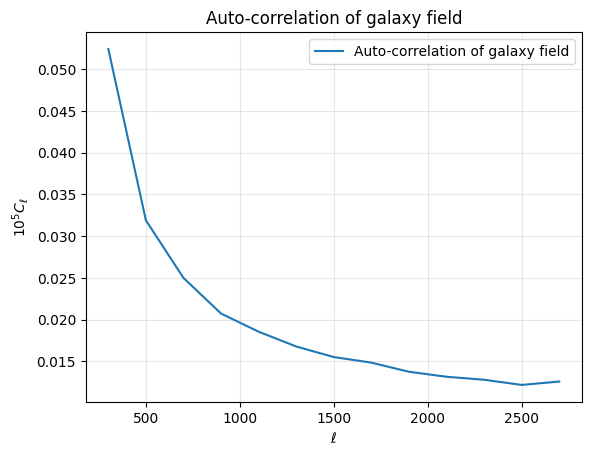

In [14]:
wsp_gal = nmt.NmtWorkspace()
wsp_gal.compute_coupling_matrix(gal_field, gal_field, b)
auto_gal = compute_master(gal_field, gal_field, wsp_gal)

plt.plot(ells_low, 1e5 * auto_gal[0], label="Auto-correlation of galaxy field")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$10^5 C_\ell$")
plt.title("Auto-correlation of galaxy field")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### direct Txg cross-correlation (maybe useless? it's not an unbiased estimator for a null kSZ signal)

In [15]:
# wsp_dir = nmt.NmtWorkspace()
# wsp_dir.compute_coupling_matrix(temp_field, gal_field, b)

# cl_txg = compute_master(temp_field, gal_field, wsp_dir)
# ell = b.get_effective_ells()

# plt.plot(ell, cl_txg[0], label="CMB x unWISE blue")
# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$C_\ell$")
# plt.xlim(ells_low[0], ells_high[-1])
# plt.title("Binned cross-power spectrum")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.show()

In [16]:
# m = mask > 0

# print("masked temp mean:", np.average(cmb_map[m], weights=mask[m]))
# print("masked gal mean:", np.average(delta_blue[m], weights=mask[m]))
# print("masked temp std:", np.std(cmb_map[m]))
# print("masked gal std:", np.std(delta_blue[m]))

In [17]:
# cm

# bin_size = 200
# n_bins = 13

# # keep only the first 13*200 = 2600 multipoles
# cm = cm[:n_bins * bin_size, :n_bins * bin_size]

# # reshape into blocks and average each 200x200 block
# cm_binned = cm.reshape(n_bins, bin_size, n_bins, bin_size).mean(axis=(1, 3))

# plt.imshow(
#     cm_binned,
#     origin="lower",
#     aspect="auto"
# )

# plt.colorbar(label="binned value")
# plt.xlabel(r"$\ell$ bin")
# plt.ylabel(r"$\ell'$ bin")
# plt.title("binned coupling matrix")

# plt.show()

### kSZ estimate

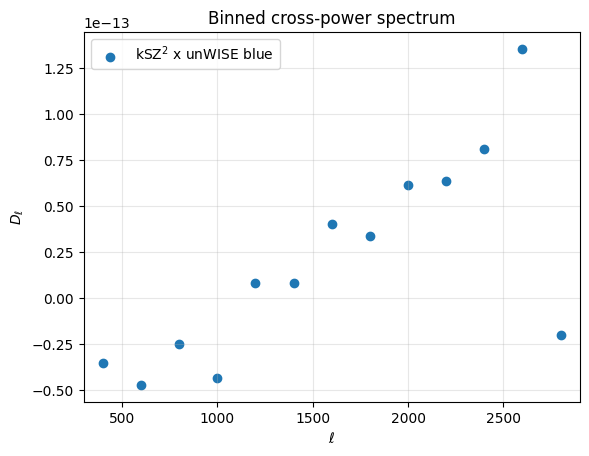

In [ ]:
# temp_field = nmt.NmtField(mask, [temp_filtered], lmax=l_max)
# temp_field_squared = nmt.NmtField(mask, [temp_filtered_squared], lmax=l_max)
# gal_field = nmt.NmtField(mask, [delta_blue], lmax=l_max)

wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(temp_field_squared, gal_field, b)

cl_t2xg = compute_master(temp_field_squared, gal_field, wsp)
ell = b.get_effective_ells()

Dl = ell * (ell + 1) * cl_t2xg[0] / (2 * np.pi)

plt.scatter(ell, Dl, label="kSZ$^2$ x unWISE blue")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned cross-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

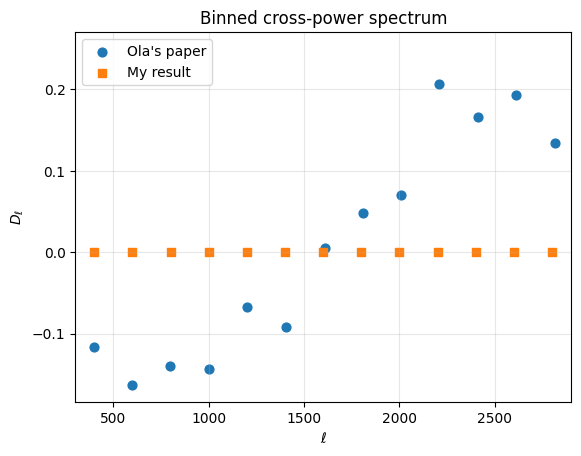

In [19]:
# data from kSZ^2 x unWISE blue cross-correlation, from Ola's paper
# extracted with webplotdigitizer from the plot in this paper: https://arxiv.org/pdf/2212.08066.pdf, fig 17

data = np.array([
    [180.94337448641977,  0.2497401807127262],
    [596.0811352462954,  -0.1629594095217642],
    [796.3828162195532,  -0.14017812399327062],
    [999.0133966767469,  -0.1437988663267863],
    [1199.9347954968391, -0.06748187247838244],
    [1402.4359214245007, -0.0913984702187064],
    [2209.589091239256,   0.2070754542107498],
    [2412.353664121214,   0.16646404505801327],
    [2612.54062950108,    0.19298645165909017],
    [2008.4892335187799,  0.07003257328990228],
    [2814.7502234008816,  0.134527687296417],
    [1809.05710414805,    0.04853420195439742],
    [1609.3078896543773,  0.005537459283387669],
    [399.5416678677467,  -0.11661237785016287]
])

plt.scatter(
    data[:, 0],
    data[:, 1],
    marker="o",
    s=40,
    label="Ola's paper"
)

plt.scatter(
    ell,
    Dl,
    marker="s",
    s=40,
    label="My result"
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.xlim(ells_low[0], ells_high[-1])
plt.title("Binned cross-power spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## synthetic power spectra

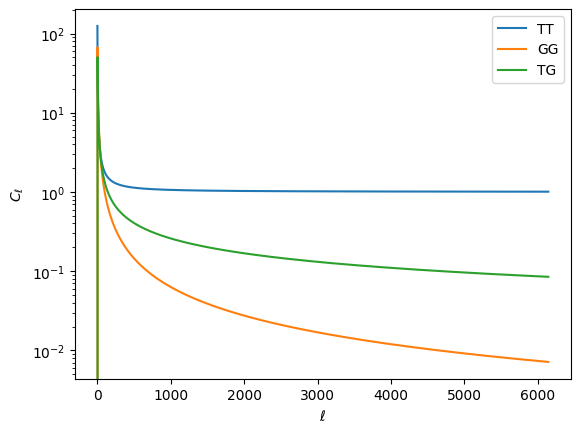

In [20]:
# let's now create a fictitious theoretical power spectrum to generate

# gaussian realizations of CMB temperature and polarization maps

larr = np.arange(3*nside)
clarr = ((larr+1.)/80.)**(-1.1)+1.
cl_tt = clarr

# gaussian realization of the galaxy overdensity map

# number density deg^-2 = 3409; number density ster^-1 = 1.12×10^7 (unWISE blue sample)
# https://arxiv.org/pdf/1909.07412

larr = np.arange(3*nside)

# avoid ell=0 divergence
ell0 = 100.
alpha = 1.2
amp = 1

cl_signal = amp * ((larr + 1.) / ell0)**(-alpha)

# shot noise: ngal per steradian
ngal_per_sr = 1.12*1e7
cl_noise = np.ones_like(larr) / ngal_per_sr

cl_gg = cl_signal + cl_noise
cl_gg[:2] = 0.0

cl_tg = np.sqrt(cl_tt * cl_gg)  #simplest way to construct a cross-spectrum 
                                #that satisfies the physical consistency condition
                                #from the Cauchy–Schwarz inequality

plt.plot(larr, cl_tt, label="TT")
plt.plot(larr, cl_gg, label="GG")
plt.plot(larr, cl_tg, label="TG")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.yscale("log")
plt.show()

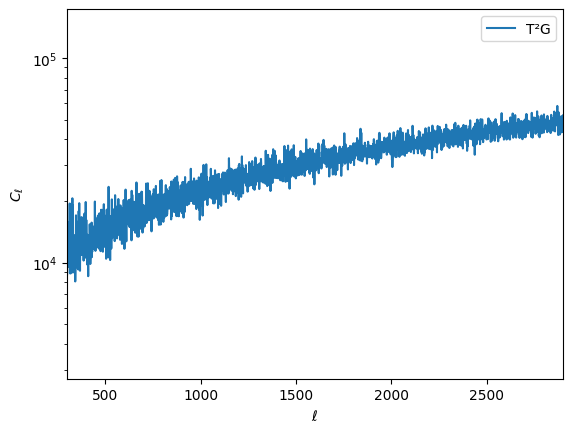

In [21]:
alms_tt = hp.synalm(cl_tt, lmax=3*nside-1)
alms_gg = hp.synalm(cl_gg, lmax=3*nside-1)
alms_tg = hp.synalm(cl_tg, lmax=3*nside-1)

alms_t2g = alms_tt**2 * alms_gg
cl_t2g = hp.alm2cl(alms_t2g)
ell_t2g = np.arange(len(cl_t2g))

plt.plot(ell_t2g, ell_t2g * (ell_t2g + 1) * cl_t2g / (2 * np.pi), label="T²G")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.yscale("log")
plt.xlim(ells_low[0], ells_high[-1])
plt.legend()
plt.show()

## random gaussian fields from power spectra

In [22]:
l_min = 300
l_max = 3000
delta_l = 200

delta_g = hp.synfast(cl_gg, nside=nside, new=True)
delta_t = hp.synfast(cl_tt, nside=nside, new=True)

# mask = hp.read_map("../masks/mask.fits")

gal_syn_field = nmt.NmtField(mask, [delta_g], lmax=l_max)
temp_syn_field = nmt.NmtField(mask, [delta_t], lmax=l_max)

ells_low = np.arange(l_min, l_max, delta_l)
ells_high = ells_low + delta_l

# make the final bin include ell = 2900
ells_high[-1] = l_max + 1

b = nmt.NmtBin.from_edges(ells_low, ells_high)

cl_dir_cross_syn = nmt.compute_full_master(temp_syn_field, gal_syn_field, b)

print(cl_dir_cross_syn.shape)

(1, 14)


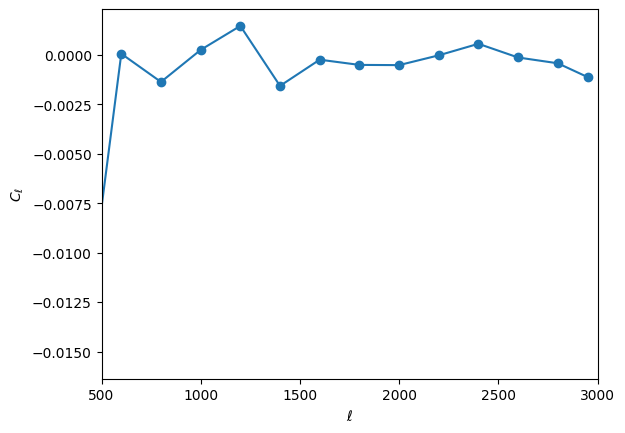

In [23]:
cl_binned = cl_dir_cross_syn[0]
ell_eff = b.get_effective_ells()

plt.plot(ell_eff, cl_binned, marker='o', linestyle='-')

plt.xlabel(r"$\ell$")
plt.xlim(500, 3000)
plt.ylabel(r"$C_\ell$")
plt.show()

In [24]:
# wsp = nmt.NmtWorkspace()
# wsp.compute_coupling_matrix(gal_syn_field, temp_syn_field, b)

# cm = wsp.get_coupling_matrix()   # or wsp.coupling_matrix

# # plt.imshow(cm, origin="lower", aspect="auto")
# # plt.colorbar(label="Coupling matrix")
# # plt.xlabel("multipole index")
# # plt.ylabel("multipole index")
# # plt.title("Coupling matrix for galaxy-temperature cross-correlation")
# # plt.show()

In [25]:
# fields
fT = temp_field      # spin-0 temperature field
fG = gal_field       # spin-0 galaxy field

# binning
b = nmt.NmtBin.from_edges(ells_low, ells_high)

# print("b.lmax:", b.lmax)
# print("fT lmax:", fT.ainfo.lmax)
# print("fG lmax:", fG.ainfo.lmax)

# print("n bins:", b.get_n_bands())
# print("ell eff:", b.get_effective_ells())

# workspaces for spectra
wTG = nmt.NmtWorkspace.from_fields(fT, fG, b)
wTT = nmt.NmtWorkspace.from_fields(fT, fT, b)
wGG = nmt.NmtWorkspace.from_fields(fG, fG, b)

# measured spectra
cl_TG = compute_master(fT, fG, wTG)
cl_TT = compute_master(fT, fT, wTT)
cl_GG = compute_master(fG, fG, wGG)

n_ell = len(cl_TG[0])

ValueError: Maximum multipoles in bins (3000) and fields (2900) are not the same.

In [ ]:
cw = nmt.NmtCovarianceWorkspace.from_fields(fT, fG, fT, fG)

In [ ]:
covar_TG_TG = nmt.gaussian_covariance(
    cw,
    0, 0, 0, 0,       # spins: T, G, T, G are all spin-0

    [cl_tt],          # T-T theory spectrum
    [cl_tg],          # T-G theory spectrum
    [cl_tg],          # G-T theory spectrum
    [cl_gg],          # G-G theory spectrum

    wTG,
    wb=wTG
    ).reshape([n_ell, 1, n_ell, 1])

cov_TG = covar_TG_TG[:, 0, :, 0]

In [ ]:
err_TG = np.sqrt(np.diag(cov_TG))

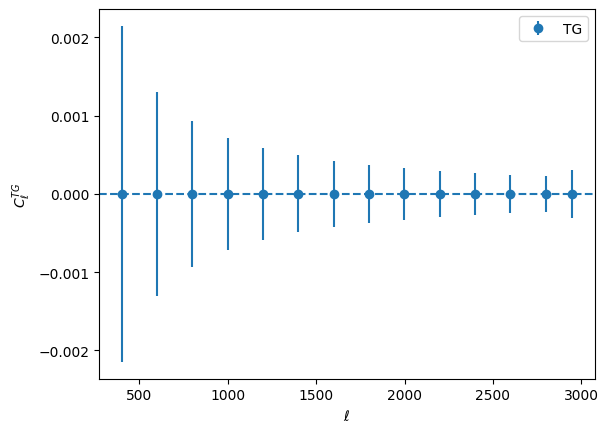

In [ ]:
plt.errorbar(
    ell_eff,
    cl_TG[0],
    yerr=err_TG,
    fmt='o',
    label="TG"
)

plt.axhline(0, linestyle="--")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{TG}$")
plt.legend()
plt.show()

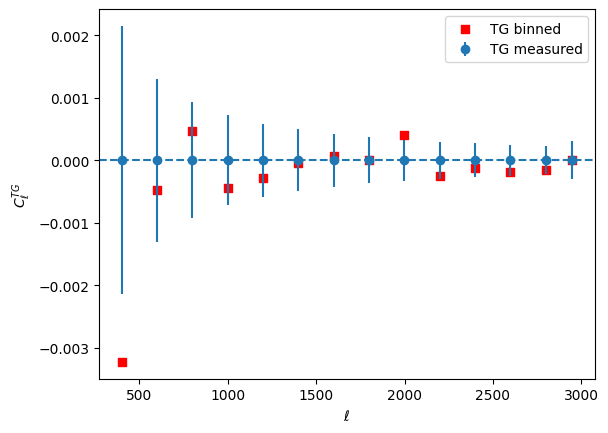

In [ ]:
plt.errorbar(
    ell_eff,
    cl_TG[0],
    yerr=err_TG,
    fmt='o',
    label="TG measured"
)

plt.scatter(
    ell_eff,
    cl_binned,
    marker='s',
    color='red',
    label="TG binned"
)

plt.axhline(0, linestyle="--")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{TG}$")
plt.legend()
plt.show()

## coupling matrix

##### we bin the cross-power spectrum signal into 13 multipole bins from l = 300 to l = 2900 with width delta_l = 200. the covariance matrices of the measurements are estimated in the Gaussian approximation, again using the Namaster code. as expected for a harmonic-space measurement with wide multipole bins, the covariance matrices are close to diagonal

In [ ]:
# print(cm.shape)
# print(np.nanmin(cm), np.nanmax(cm))
# print(np.count_nonzero(cm))
# print(np.diag(cm)[:10])
# print(np.max(np.abs(cm - np.diag(np.diag(cm)))))

# plt.imshow(np.log10(np.abs(cm) + 1e-15), origin="lower", aspect="auto")
# plt.colorbar(label=r"$\log_{10}|M_{\ell\ell'}|$")
# plt.xlabel(r"$\ell'$ index")
# plt.ylabel(r"$\ell$ index")
# plt.title("log coupling matrix")
# plt.show()

# cm_off = cm.copy()
# np.fill_diagonal(cm_off, 0)

# plt.imshow(np.log10(np.abs(cm_off) + 1e-15), origin="lower", aspect="auto")
# plt.colorbar(label=r"$\log_{10}|M_{\ell\ell'}|$, off-diagonal")
# plt.xlabel(r"$\ell'$ index")
# plt.ylabel(r"$\ell$ index")
# plt.title("off-diagonal coupling")
# plt.show()

In [ ]:
# b4 = nmt.NmtBin.from_nside_linear(nside, 4)
# b100 = nmt.NmtBin.from_nside_linear(nside, 100)

# w4 = nmt.NmtWorkspace()
# w4.compute_coupling_matrix(gal_field, temp_field, b4)

# w100 = nmt.NmtWorkspace()
# w100.compute_coupling_matrix(gal_field, temp_field, b100)

# cm4 = w4.get_coupling_matrix()
# cm100 = w100.get_coupling_matrix()

# print(cm4.shape, cm100.shape)

In [ ]:
# win4 = w4.get_bandpower_windows()
# win100 = w100.get_bandpower_windows()

# print("win4:", win4.shape)
# print("win100:", win100.shape)
# print("nbands 4:", len(b4.get_effective_ells()))
# print("nbands 100:", len(b100.get_effective_ells()))

In [ ]:
# ell = np.arange(win4.shape[-1])

# plt.plot(ell, win4[0, 100, 0, :], label="bin width 4")
# plt.plot(ell, win100[0, 4, 0, :], label="bin width 100")
# plt.xlabel(r"$\ell$")
# plt.ylabel("bandpower window")
# plt.legend()
# plt.show()

# print(b4.get_effective_ells()[100])
# print(b100.get_effective_ells()[4])

# plt.imshow(np.log10(np.abs(win4[0, :, 0, :]) + 1e-15),
#            origin="lower", aspect="auto")
# plt.colorbar(label=r"$\log_{10}|W_{b\ell}|$")
# plt.title("bandpower windows, bin width 4")
# plt.xlabel(r"$\ell$")
# plt.ylabel("bandpower bin")
# plt.show()

# plt.imshow(np.log10(np.abs(win100[0, :, 0, :]) + 1e-15),
#            origin="lower", aspect="auto")
# plt.colorbar(label=r"$\log_{10}|W_{b\ell}|$")
# plt.title("bandpower windows, bin width 100")
# plt.xlabel(r"$\ell$")
# plt.ylabel("bandpower bin")
# plt.show()

### synthetic galaxy overdensity map visualisation

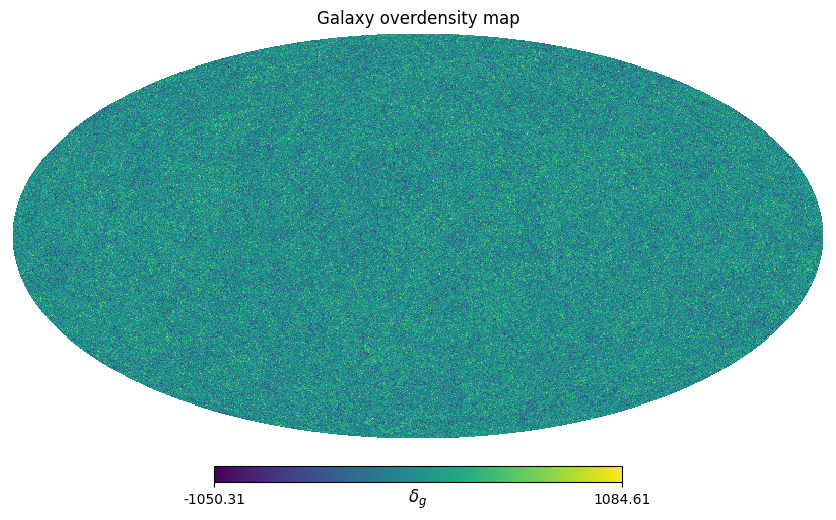

In [ ]:
delta_g = hp.synfast(cl_gg, nside=nside, new=True)

hp.mollview(delta_g, title="Galaxy overdensity map", unit=r"$\delta_g$")

# mask_resampled = mask
# if hp.get_nside(mask_resampled) != nside:
#     mask_resampled = hp.ud_grade(mask_resampled, nside_out=nside)

# f_g = nmt.NmtField(mask_resampled, [delta_g])